In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [4]:
np.random.seed(42)
x,y= make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2)

In [5]:
x.shape

(500, 2)

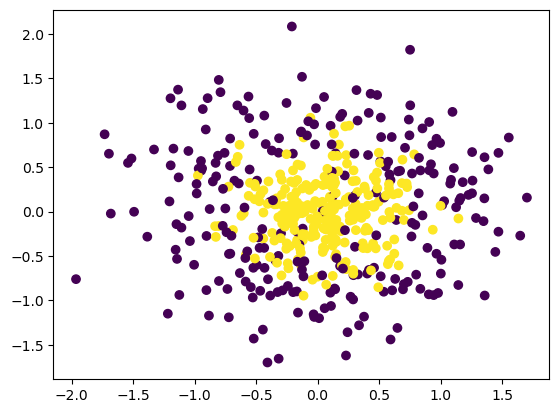

In [9]:
plt.scatter(x[:,0] ,x[:,1], c=y)

In [10]:
from sklearn.tree import DecisionTreeClassifier

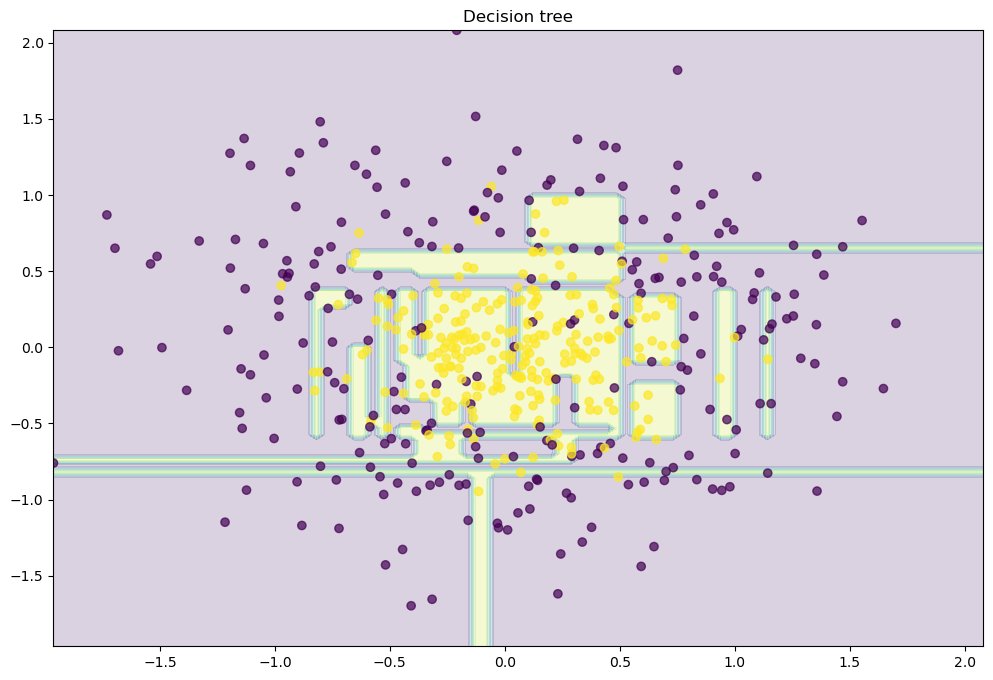

In [14]:
# this visualizeation using only one decision tree

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(x_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(x.min(), x.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(x[:,0], x[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

In [15]:

from sklearn.ensemble import RandomForestClassifier

In [26]:

n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    x= np.random.rand(n_samples) * 10 - 5
    x = np.sort(x).ravel()
    y = np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    x= x.reshape((n_samples, 1))

    return x, y

x_train, y_train = generate(n_samples=n_train, noise=noise)
x_test, y_test = generate(n_samples=n_test, noise=noise)

In [27]:

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(x_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(x.min(), x.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(x[:,0], x[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()
     

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

(-5.0, 5.0)

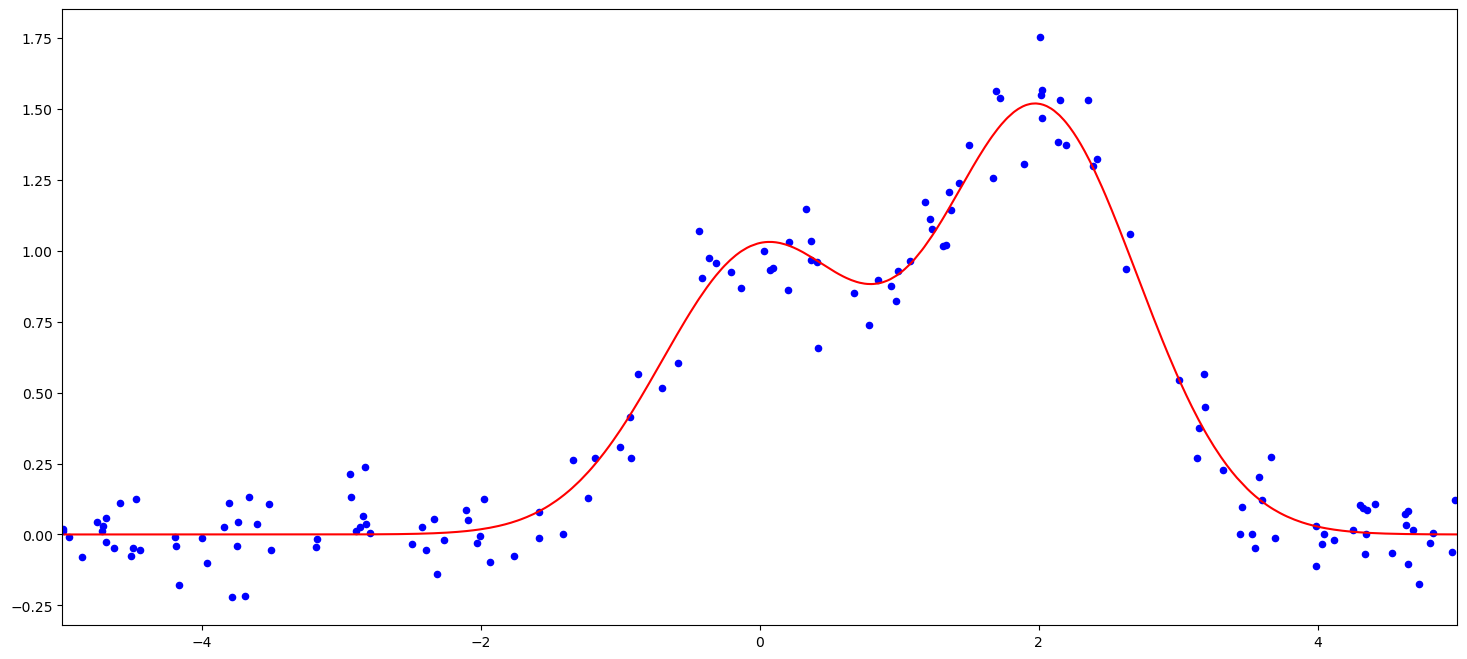

In [28]:

plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.xlim([-5, 5])

Text(0.5, 1.0, 'Decision tree, MSE = 66.92')

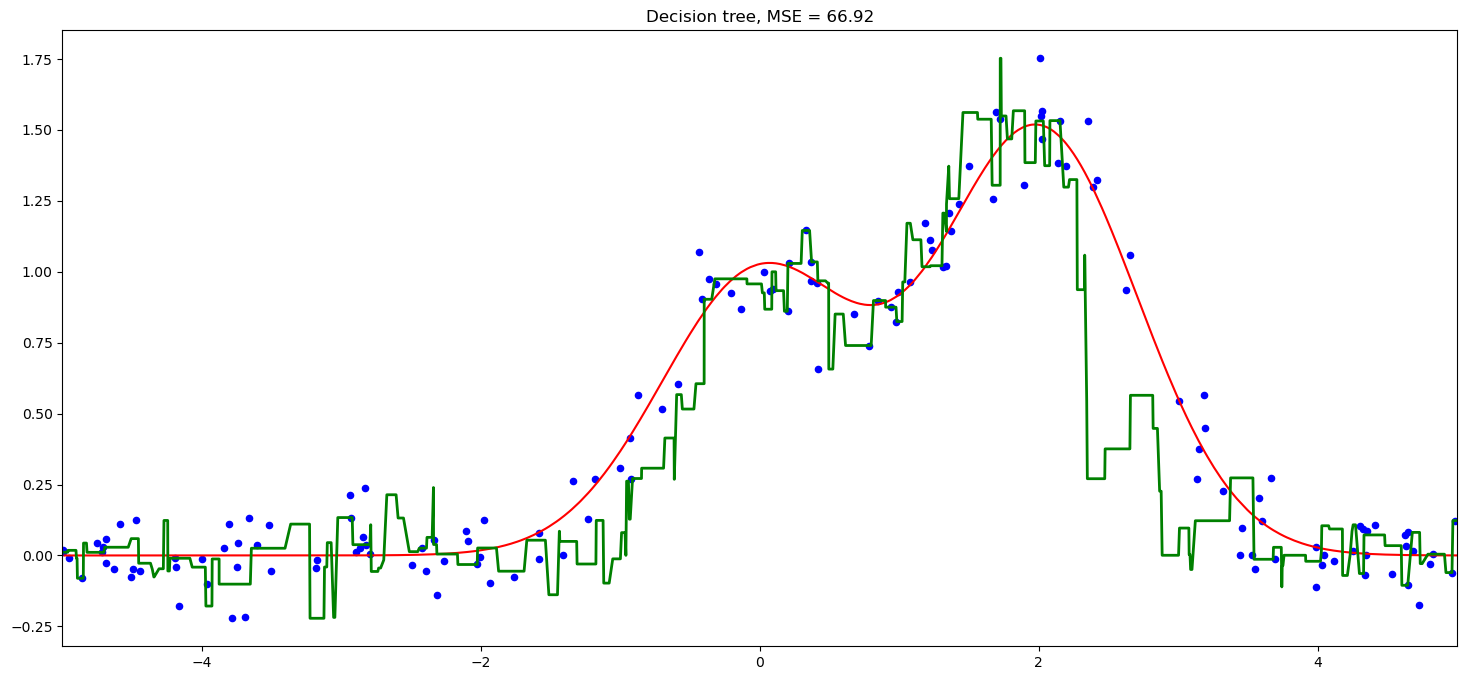

In [29]:

# One decision tree regressor
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.plot(x_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - d_predict) ** 2))

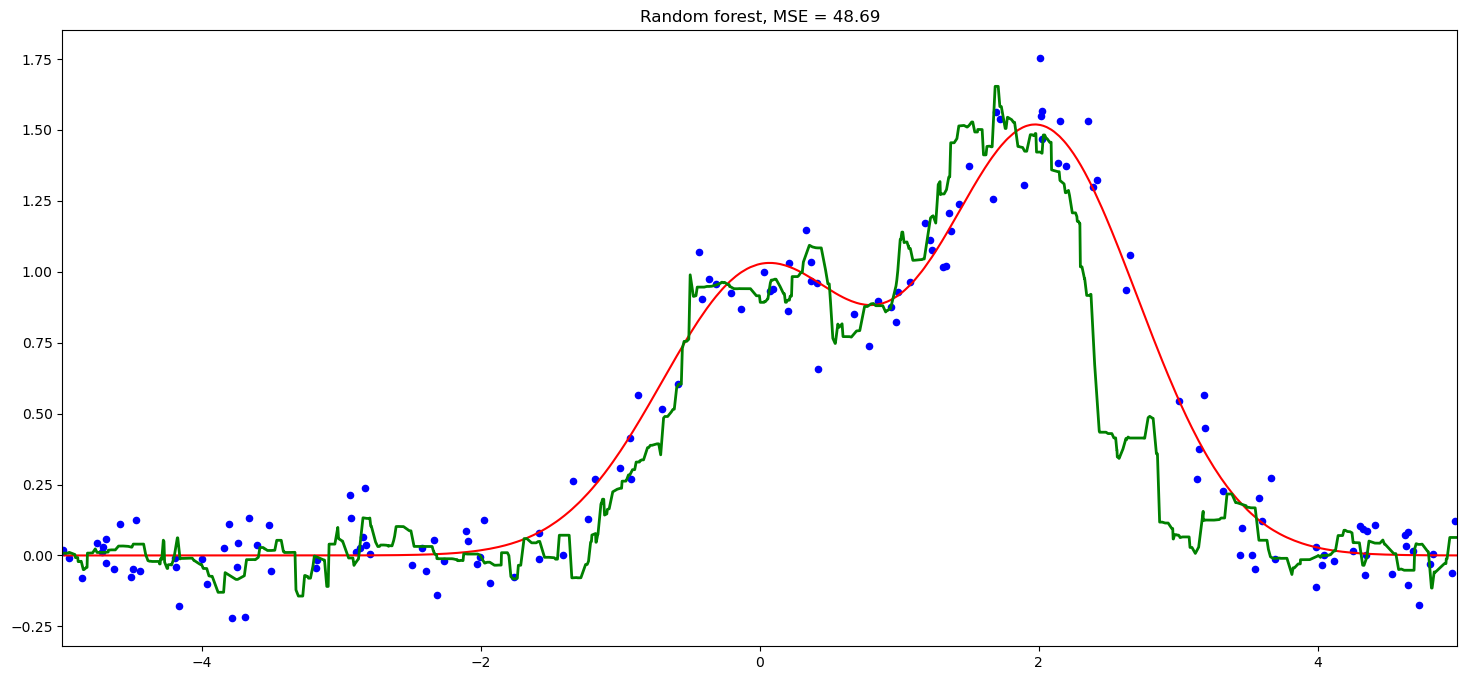

In [30]:

# Random Forest
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(x_test)

plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.plot(x_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));